# Binance Cycle Regime + MA Heatmap + Sweep/Reclaim Backtest

Bu notebook V2/V3'teki ana problemi hedefler: trend ortasinda tekrar tekrar long basmak yerine, once rejimi secer, sonra `rise -> pullback -> mild recovery -> compression -> breakout` cycle'ini bekler.

## Metodoloji

Bu versiyonda POC sinyali tek basina giris sebebi degil.

1. Once MA return heatmap ile trend filtresi kalibre edilir.
2. Secilen fast/slow EMA ciftinden `real_uptrend` uretilir.
3. Cycle state machine su sirayi arar:
   - impulse/rise
   - peak sonrasi anlamli pullback
   - valley sonrasi hafif recovery
   - dusuk volatilite ve dar range ile durağan/compression bolgesi
   - compression high ustu breakout/reclaim
4. Entry sadece breakout/reclaim'de gelir; trend ortasinda surekli yeniden entry acilmaz.
5. Stop 3x kaldiracta ana paranin %1 riskini asmayacak sekilde caplenir.

In [1]:
import os
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/codex_numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib_cache")
os.environ.setdefault("MPLBACKEND", "Agg")

from datetime import datetime, timezone, timedelta
from itertools import product
import math
import time
import warnings

import numpy as np
import pandas as pd

try:
    import ccxt
except ImportError as exc:
    raise ImportError("ccxt lazim. Eski proje .venv'i ile ac.") from exc

try:
    import vectorbt as vbt
except Exception as exc:
    raise ImportError("vectorbt import edilemedi. Eski proje .venv'i ile ac.") from exc

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

print("pandas", pd.__version__)
print("vectorbt", vbt.__version__)
print("ccxt", ccxt.__version__)

pandas 2.3.3
vectorbt 1.0.0
ccxt 4.5.67


In [2]:
# ==========
# Settings
# ==========

SYMBOL = "BTCUSDT"
CCXT_SYMBOL = "BTC/USDT"
CCXT_EXCHANGE_ID = "binance"
CCXT_DEFAULT_TYPE = "spot"
TIMEFRAME = "5m"
PANDAS_FREQ = "5min"
TOTAL_BARS = 3000
PAGE_LIMIT = 1000

FEE = 0.0004
SLIPPAGE = 0.0002
INIT_CASH = 100_000
LEVERAGE = 3.0
MAX_PRINCIPAL_RISK_PCT = 0.01
INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP = True
MIN_EFFECTIVE_SL_STOP = 0.0005

FAST_GRID = [6, 9, 12, 18, 24, 36, 48]
SLOW_GRID = [36, 48, 72, 96, 144, 192, 288]

V4_PARAMS = {
    "train_frac": 0.70,
    "ma_slope_lookback": 12,
    "ma_slope_min_bps": -2.0,
    "poc_window": 96,
    "poc_bins": 36,
    "value_area_pct": 0.70,
    "atr_window": 20,
    "vol_window": 48,
    "compression_window": 24,
    "compression_quantile_window": 288,
    "range_quantile": 0.40,
    "atr_quantile": 0.50,
    "near_poc_bps": 45.0,
    "min_pullback_bps": 70.0,
    "min_recovery_bps": 22.0,
    "min_compression_bars": 5,
    "max_cycle_bars": 220,
    "breakout_buffer_bps": 4.0,
    "valley_close_tol_bps": 8.0,
    "entry_vol_ratio_thr": 0.85,
    "entry_vol_ratio_max": 8.0,
    "entry_mom_bps_thr": 20.0,
    "cooldown_bars": 36,
    "hold_bars": 96,
    "sl_stop": 0.0060,
    "tp_stop": 0.0080,
    "leverage": LEVERAGE,
    "max_principal_risk_pct": MAX_PRINCIPAL_RISK_PCT,
    "include_costs_in_risk_cap": INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP,
}

print("V4_PARAMS", V4_PARAMS)

V4_PARAMS {'train_frac': 0.7, 'ma_slope_lookback': 12, 'ma_slope_min_bps': -2.0, 'poc_window': 96, 'poc_bins': 36, 'value_area_pct': 0.7, 'atr_window': 20, 'vol_window': 48, 'compression_window': 24, 'compression_quantile_window': 288, 'range_quantile': 0.4, 'atr_quantile': 0.5, 'near_poc_bps': 45.0, 'min_pullback_bps': 70.0, 'min_recovery_bps': 22.0, 'min_compression_bars': 5, 'max_cycle_bars': 220, 'breakout_buffer_bps': 4.0, 'valley_close_tol_bps': 8.0, 'entry_vol_ratio_thr': 0.85, 'entry_vol_ratio_max': 8.0, 'entry_mom_bps_thr': 20.0, 'cooldown_bars': 36, 'hold_bars': 96, 'sl_stop': 0.006, 'tp_stop': 0.008, 'leverage': 3.0, 'max_principal_risk_pct': 0.01, 'include_costs_in_risk_cap': True}


In [3]:
def timeframe_to_ms(timeframe):
    unit = timeframe[-1]
    value = int(timeframe[:-1])
    if unit == "m":
        return value * 60_000
    if unit == "h":
        return value * 60 * 60_000
    if unit == "d":
        return value * 24 * 60 * 60_000
    if unit == "w":
        return value * 7 * 24 * 60 * 60_000
    raise ValueError(f"Unsupported timeframe: {timeframe}")


def make_spot_exchange():
    klass = getattr(ccxt, CCXT_EXCHANGE_ID)
    ex = klass({
        "enableRateLimit": True,
        "timeout": 30000,
        "options": {
            "defaultType": CCXT_DEFAULT_TYPE,
            # Critical: Binance CCXT otherwise tries futures exchangeInfo too.
            "fetchMarkets": ["spot"],
            "adjustForTimeDifference": True,
        },
    })
    return ex


def ohlcv_to_frame(raw, timeframe=TIMEFRAME):
    df = pd.DataFrame(raw, columns=["open_time", "open", "high", "low", "close", "volume"])
    if df.empty:
        return df
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["close_time"] = df["open_time"] + pd.to_timedelta(timeframe_to_ms(timeframe), unit="ms")
    return df.set_index("open_time").sort_index().dropna(subset=["open", "high", "low", "close", "volume"])


def fetch_ohlcv_page(symbol=CCXT_SYMBOL, timeframe=TIMEFRAME, since=None, limit=PAGE_LIMIT, exchange=None):
    ex = exchange or make_spot_exchange()
    raw = ex.fetch_ohlcv(symbol, timeframe=timeframe, since=since, limit=limit)
    return ohlcv_to_frame(raw, timeframe=timeframe)


def fetch_ohlcv_paginated(symbol=CCXT_SYMBOL, timeframe=TIMEFRAME, total_bars=TOTAL_BARS, page_limit=PAGE_LIMIT):
    tf_ms = timeframe_to_ms(timeframe)
    now_ms = int(pd.Timestamp.utcnow().timestamp() * 1000)
    since = now_ms - int(total_bars * tf_ms * 1.08)
    ex = make_spot_exchange()
    frames = []
    last_ts = None
    errors = []

    while True:
        current_len = len(pd.concat(frames).drop_duplicates().sort_index()) if frames else 0
        caught_up = last_ts is not None and last_ts >= now_ms - 2 * tf_ms
        if current_len >= total_bars and caught_up:
            break
        try:
            page = fetch_ohlcv_page(symbol, timeframe, since=since, limit=page_limit, exchange=ex)
        except Exception as exc:
            errors.append(f"{type(exc).__name__}: {str(exc)[:240]}")
            if frames:
                break
            raise RuntimeError("Ilk OHLCV sayfasi cekilemedi:\n" + "\n".join(errors)) from exc

        if page.empty:
            break
        frames.append(page)
        ts = int(page.index[-1].timestamp() * 1000)
        if last_ts is not None and ts <= last_ts:
            break
        last_ts = ts
        since = ts + tf_ms
        time.sleep(0.25)
        if len(frames) > math.ceil(total_bars / page_limit) + 3:
            break

    out = pd.concat(frames).sort_index()
    out = out[~out.index.duplicated(keep="last")]
    return out.tail(total_bars)


try:
    ohlcv_raw = fetch_ohlcv_paginated(CCXT_SYMBOL, TIMEFRAME, TOTAL_BARS, PAGE_LIMIT)
except Exception as exc:
    print("Paginated fetch basarisiz; tek sayfa fallback deneniyor:", type(exc).__name__, str(exc)[:600])
    ohlcv_raw = fetch_ohlcv_page(CCXT_SYMBOL, TIMEFRAME, since=None, limit=min(PAGE_LIMIT, TOTAL_BARS))

print("ohlcv_raw", ohlcv_raw.shape, ohlcv_raw.index.min(), ohlcv_raw.index.max())
display(ohlcv_raw.tail())

Paginated fetch basarisiz; tek sayfa fallback deneniyor: RuntimeError Ilk OHLCV sayfasi cekilemedi:
NetworkError: binance GET https://api.binance.com/api/v3/exchangeInfo
ohlcv_raw (1000, 6) 2026-07-18 04:40:00+00:00 2026-07-21 15:55:00+00:00


,open,high,low,close,volume,close_time
open_time,,,,,,
2026-07-21 15:35:00+00:00,66571.99,66712.00,66517.52,66700.01,64.49843,2026-07-21 15:40:00+00:00
2026-07-21 15:40:00+00:00,66700.01,66700.01,66609.51,66614.85,58.19662,2026-07-21 15:45:00+00:00
2026-07-21 15:45:00+00:00,66614.84,66697.31,66591.99,66672.36,55.88437,2026-07-21 15:50:00+00:00
2026-07-21 15:50:00+00:00,66672.37,66710.00,66655.04,66684.55,38.05612,2026-07-21 15:55:00+00:00
2026-07-21 15:55:00+00:00,66684.55,66720.66,66667.49,66715.89,17.92778,2026-07-21 16:00:00+00:00


In [4]:
def ohlcv_frame(df):
    f = df.copy().rename(columns={c: c.lower() for c in df.columns})
    if "open_time" in f.columns and not isinstance(f.index, pd.DatetimeIndex):
        f["open_time"] = pd.to_datetime(f["open_time"], utc=True)
        f = f.set_index("open_time")
    required = ["open", "high", "low", "close", "volume"]
    missing = [c for c in required if c not in f.columns]
    if missing:
        raise ValueError(f"OHLCV kolonlari eksik: {missing}")
    for col in required:
        f[col] = pd.to_numeric(f[col], errors="coerce")
    return f[required].dropna().sort_index()


def rolling_zscore(s, window, min_periods=None):
    min_periods = min_periods or max(5, int(window) // 3)
    mean = s.rolling(window, min_periods=min_periods).mean()
    std = s.rolling(window, min_periods=min_periods).std(ddof=0)
    return (s - mean) / std.replace(0, np.nan)


def _profile_from_window(high, low, close, volume, bins=36, value_area_pct=0.70):
    hmax = float(np.nanmax(high))
    lmin = float(np.nanmin(low))
    if not np.isfinite(hmax) or not np.isfinite(lmin) or hmax <= lmin:
        return np.nan, np.nan, np.nan

    edges = np.linspace(lmin, hmax, int(bins) + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    profile = np.zeros(int(bins), dtype=float)

    for h, l, c, v in zip(high, low, close, volume):
        if not np.isfinite(v) or v <= 0:
            continue
        if not np.isfinite(h) or not np.isfinite(l) or h <= l:
            idx = np.searchsorted(edges, c, side="right") - 1
            if 0 <= idx < len(profile):
                profile[idx] += v
            continue
        idxs = np.where((edges[:-1] <= h) & (edges[1:] >= l))[0]
        if len(idxs):
            profile[idxs] += v / len(idxs)

    total = profile.sum()
    if total <= 0:
        return np.nan, np.nan, np.nan

    poc_idx = int(np.argmax(profile))
    poc = centers[poc_idx]
    selected = {poc_idx}
    cum_vol = profile[poc_idx]
    left = poc_idx - 1
    right = poc_idx + 1
    target = total * float(value_area_pct)

    while cum_vol < target and (left >= 0 or right < len(profile)):
        left_vol = profile[left] if left >= 0 else -1
        right_vol = profile[right] if right < len(profile) else -1
        if right_vol >= left_vol:
            selected.add(right)
            cum_vol += max(right_vol, 0)
            right += 1
        else:
            selected.add(left)
            cum_vol += max(left_vol, 0)
            left -= 1

    idx_sorted = sorted(selected)
    val = edges[max(0, idx_sorted[0])]
    vah = edges[min(len(edges) - 1, idx_sorted[-1] + 1)]
    return poc, vah, val


def add_rolling_poc(df, window=96, bins=36, value_area_pct=0.70):
    f = df.copy()
    poc = np.full(len(f), np.nan)
    vah = np.full(len(f), np.nan)
    val = np.full(len(f), np.nan)
    highs = f["high"].to_numpy(dtype=float)
    lows = f["low"].to_numpy(dtype=float)
    closes = f["close"].to_numpy(dtype=float)
    vols = f["volume"].to_numpy(dtype=float)
    w = int(window)

    for i in range(w, len(f)):
        j = slice(i - w, i)
        poc[i], vah[i], val[i] = _profile_from_window(
            highs[j], lows[j], closes[j], vols[j], bins=bins, value_area_pct=value_area_pct
        )

    f["poc"] = poc
    f["vah"] = vah
    f["val"] = val
    f["poc_dist_bps"] = (f["close"] / f["poc"] - 1) * 10_000
    return f


def rsi(close, window=14):
    delta = close.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    rs = up.ewm(alpha=1 / window, adjust=False).mean() / down.ewm(alpha=1 / window, adjust=False).mean().replace(0, np.nan)
    return 100 - (100 / (1 + rs))

BEST_FAST 48 BEST_SLOW 192


,fast,slow,train_total_return,test_total_return,train_max_drawdown,test_max_drawdown,ma_entries,score
44,48,192,-0.017162,0.032060,-0.026598,-0.010266,10,-0.029095
33,24,192,-0.017295,0.032060,-0.026729,-0.010266,10,-0.029327
39,36,192,-0.018658,0.032060,-0.028079,-0.010266,10,-0.031703
26,18,192,-0.018699,0.028948,-0.028120,-0.010266,11,-0.032551
45,48,288,-0.019378,0.032060,-0.028793,-0.010266,11,-0.032958
19,12,192,-0.019987,0.028948,-0.029396,-0.010266,12,-0.034797
40,36,288,-0.020789,0.032060,-0.030190,-0.010266,11,-0.035417
12,9,192,-0.021588,0.028948,-0.030981,-0.010266,13,-0.037587
32,24,144,-0.021620,0.028717,-0.031710,-0.010562,12,-0.038223
38,36,144,-0.022477,0.028717,-0.032559,-0.010562,12,-0.039717


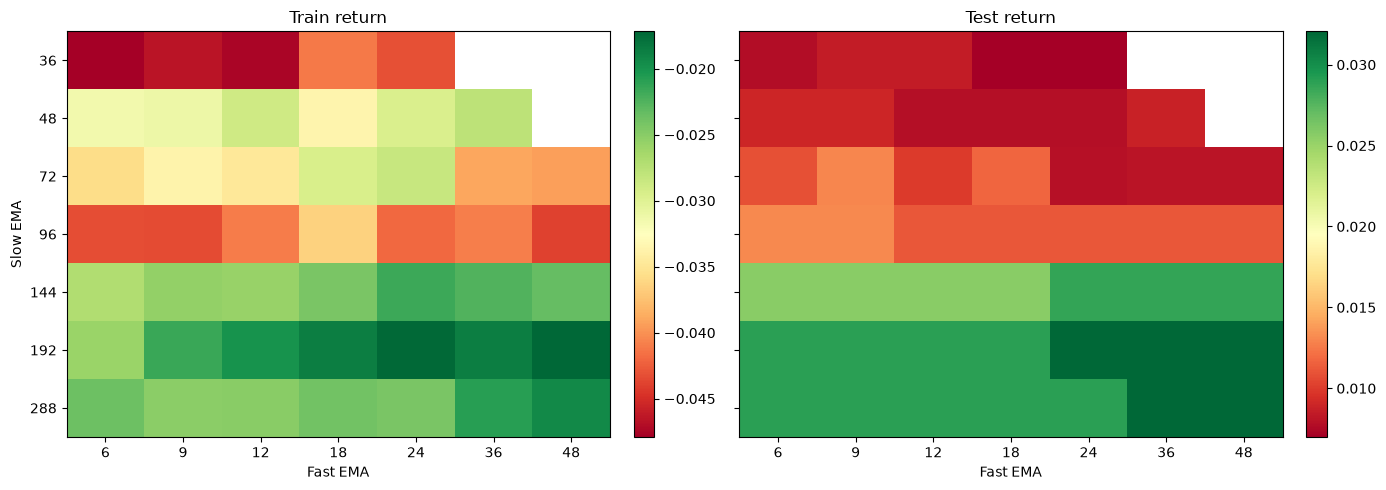

In [5]:
def max_drawdown_from_returns(ret):
    equity = (1 + ret.fillna(0)).cumprod()
    dd = equity / equity.cummax() - 1
    return float(dd.min())


def evaluate_ma_pair(close, fast, slow, train_frac=0.70):
    ema_fast = close.ewm(span=int(fast), adjust=False).mean()
    ema_slow = close.ewm(span=int(slow), adjust=False).mean()
    slope_bps = ema_slow.pct_change(V4_PARAMS["ma_slope_lookback"]) * 10_000
    pos = ((ema_fast > ema_slow) & (close > ema_slow) & (slope_bps >= V4_PARAMS["ma_slope_min_bps"])).astype(float)
    ret = close.pct_change().fillna(0)
    turnover = pos.diff().abs().fillna(pos)
    strat_ret = pos.shift(1).fillna(0) * ret - turnover * (FEE + SLIPPAGE)

    cut = max(1, int(len(close) * train_frac))
    train_ret = strat_ret.iloc[:cut]
    test_ret = strat_ret.iloc[cut:]
    train_total = float((1 + train_ret).prod() - 1)
    test_total = float((1 + test_ret).prod() - 1) if len(test_ret) else np.nan
    train_dd = max_drawdown_from_returns(train_ret)
    test_dd = max_drawdown_from_returns(test_ret) if len(test_ret) else np.nan
    trades = int((pos.diff() > 0).sum())
    score = train_total - 0.75 * abs(train_dd) + 0.25 * np.nan_to_num(test_total, nan=0.0)
    return {
        "fast": int(fast),
        "slow": int(slow),
        "train_total_return": train_total,
        "test_total_return": test_total,
        "train_max_drawdown": train_dd,
        "test_max_drawdown": test_dd,
        "ma_entries": trades,
        "score": float(score),
    }


def evaluate_ma_heatmap(df, fast_grid=FAST_GRID, slow_grid=SLOW_GRID):
    close = df["close"].astype(float)
    rows = []
    for fast, slow in product(fast_grid, slow_grid):
        if fast >= slow:
            continue
        rows.append(evaluate_ma_pair(close, fast, slow, V4_PARAMS["train_frac"]))
    res = pd.DataFrame(rows).sort_values(["score", "train_total_return"], ascending=False)
    return res


def add_selected_ma_features(df, fast, slow):
    f = df.copy()
    f["ema_fast_sel"] = f["close"].ewm(span=int(fast), adjust=False).mean()
    f["ema_slow_sel"] = f["close"].ewm(span=int(slow), adjust=False).mean()
    f["ema_spread_bps"] = (f["ema_fast_sel"] / f["ema_slow_sel"] - 1) * 10_000
    f["ema_slow_slope_bps"] = f["ema_slow_sel"].pct_change(V4_PARAMS["ma_slope_lookback"]) * 10_000
    f["real_uptrend"] = (
        (f["ema_fast_sel"] > f["ema_slow_sel"])
        & (f["close"] > f["ema_slow_sel"])
        & (f["ema_slow_slope_bps"] >= V4_PARAMS["ma_slope_min_bps"])
    )
    return f


base_ohlcv = ohlcv_frame(ohlcv_raw)
ma_grid = evaluate_ma_heatmap(base_ohlcv)
best_ma = ma_grid.iloc[0].to_dict()
BEST_FAST = int(best_ma["fast"])
BEST_SLOW = int(best_ma["slow"])

print("BEST_FAST", BEST_FAST, "BEST_SLOW", BEST_SLOW)
display(ma_grid.head(20))

def plot_ma_heatmaps(grid):
    if grid.empty:
        print("MA heatmap icin sonuc yok.")
        return
    train_pivot = grid.pivot_table(index="slow", columns="fast", values="train_total_return")
    test_pivot = grid.pivot_table(index="slow", columns="fast", values="test_total_return")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, pivot, title in zip(axes, [train_pivot, test_pivot], ["Train return", "Test return"]):
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([str(int(x)) for x in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([str(int(x)) for x in pivot.index])
        ax.set_xlabel("Fast EMA")
        ax.set_title(title)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[0].set_ylabel("Slow EMA")
    plt.tight_layout()
    plt.show()

plot_ma_heatmaps(ma_grid)

In [6]:
def build_v4_features(df, fast=BEST_FAST, slow=BEST_SLOW, params=None):
    params = params or V4_PARAMS
    f = ohlcv_frame(df)
    f = add_rolling_poc(
        f,
        window=params["poc_window"],
        bins=params["poc_bins"],
        value_area_pct=params["value_area_pct"],
    )
    f = add_selected_ma_features(f, fast, slow)
    f["ret_1"] = f["close"].pct_change()
    f["momentum_bps"] = f["close"].pct_change(12) * 10_000
    f["rsi_14"] = rsi(f["close"], 14)
    f["atr_bps"] = ((f["high"] - f["low"]).rolling(params["atr_window"], min_periods=5).mean() / f["close"]) * 10_000
    f["range_bps"] = (
        (f["high"].rolling(params["compression_window"], min_periods=8).max()
         - f["low"].rolling(params["compression_window"], min_periods=8).min())
        / f["close"] * 10_000
    )
    f["range_q"] = f["range_bps"].rolling(params["compression_quantile_window"], min_periods=80).quantile(params["range_quantile"])
    f["atr_q"] = f["atr_bps"].rolling(params["compression_quantile_window"], min_periods=80).quantile(params["atr_quantile"])
    f["volume_ratio"] = f["volume"] / f["volume"].rolling(params["vol_window"], min_periods=12).median().replace(0, np.nan)
    f["volume_z"] = rolling_zscore(f["volume"], params["vol_window"])
    f["near_poc"] = f["poc_dist_bps"].abs() <= params["near_poc_bps"]
    f["compression"] = (
        (f["range_bps"] <= f["range_q"])
        & (f["atr_bps"] <= f["atr_q"])
        & f["near_poc"].fillna(False)
    )
    return f.replace([np.inf, -np.inf], np.nan)


def add_cycle_state(f, params=None):
    params = params or V4_PARAMS
    out = f.copy()
    n = len(out)
    state_arr = np.full(n, "idle", dtype=object)
    entry = np.zeros(n, dtype=bool)
    cycle_id_arr = np.zeros(n, dtype=int)
    peak_arr = np.full(n, np.nan)
    valley_arr = np.full(n, np.nan)
    box_high_arr = np.full(n, np.nan)
    box_low_arr = np.full(n, np.nan)
    comp_count_arr = np.zeros(n, dtype=int)

    high = out["high"].to_numpy(float)
    low = out["low"].to_numpy(float)
    close = out["close"].to_numpy(float)
    trend = out["real_uptrend"].fillna(False).to_numpy(bool)
    compression = out["compression"].fillna(False).to_numpy(bool)
    volume_ratio = out["volume_ratio"].fillna(0).to_numpy(float)
    momentum_bps = out["momentum_bps"].fillna(-999).to_numpy(float)

    state = "idle"
    cycle_id = 0
    peak = np.nan
    valley = np.nan
    valley_floor = np.nan
    box_high = np.nan
    box_low = np.nan
    comp_count = 0
    compression_seen = False
    cycle_start_i = 0
    last_entry_i = -10_000

    for i in range(n):
        phase = state

        if state == "idle":
            if trend[i]:
                state = "impulse"
                phase = state
                peak = high[i]
                valley = np.nan
                box_high = np.nan
                box_low = np.nan
                comp_count = 0
                compression_seen = False
                cycle_start_i = i

        elif state == "impulse":
            peak = max(peak, high[i]) if np.isfinite(peak) else high[i]
            dd_bps = (close[i] / peak - 1) * 10_000 if np.isfinite(peak) and peak > 0 else 0
            phase = "impulse"
            if dd_bps <= -float(params["min_pullback_bps"]):
                state = "pullback"
                phase = state
                cycle_id += 1
                valley = low[i]
                valley_floor = valley * (1 - float(params["valley_close_tol_bps"]) / 10_000)
                cycle_start_i = i
            elif not trend[i] and i - cycle_start_i > int(params["max_cycle_bars"]):
                state = "idle"

        elif state == "pullback":
            phase = "pullback"
            if low[i] < valley:
                valley = low[i]
                valley_floor = valley * (1 - float(params["valley_close_tol_bps"]) / 10_000)
            recovery_bps = (close[i] / valley - 1) * 10_000 if np.isfinite(valley) and valley > 0 else 0
            if recovery_bps >= float(params["min_recovery_bps"]) and close[i] > valley_floor:
                state = "compression"
                phase = state
                box_high = high[i]
                box_low = low[i]
                comp_count = 1 if compression[i] else 0
                compression_seen = comp_count >= int(params["min_compression_bars"])
            elif i - cycle_start_i > int(params["max_cycle_bars"]):
                state = "idle"

        elif state == "compression":
            phase = "compression"
            if close[i] < valley_floor:
                state = "idle"
                phase = "invalidated"
            else:
                prior_box_high = box_high
                box_high = max(box_high, high[i]) if np.isfinite(box_high) else high[i]
                box_low = min(box_low, low[i]) if np.isfinite(box_low) else low[i]
                if compression[i]:
                    comp_count += 1
                else:
                    comp_count = max(0, comp_count - 1)
                compression_seen = compression_seen or comp_count >= int(params["min_compression_bars"])

                breakout_level = prior_box_high * (1 + float(params["breakout_buffer_bps"]) / 10_000) if np.isfinite(prior_box_high) else np.inf
                cooldown_ok = i - last_entry_i >= int(params["cooldown_bars"])
                breakout_ok = (
                    compression_seen
                    and trend[i]
                    and close[i] > breakout_level
                    and close[i] > out["ema_fast_sel"].iloc[i]
                    and volume_ratio[i] >= float(params["entry_vol_ratio_thr"])
                    and volume_ratio[i] <= float(params.get("entry_vol_ratio_max", np.inf))
                    and momentum_bps[i] >= float(params["entry_mom_bps_thr"])
                    and cooldown_ok
                )
                if breakout_ok:
                    entry[i] = True
                    last_entry_i = i
                    state = "post_breakout"
                    phase = "breakout"
            if i - cycle_start_i > int(params["max_cycle_bars"]):
                state = "idle"

        elif state == "post_breakout":
            phase = "post_breakout"
            if i - last_entry_i > int(params["cooldown_bars"]) or not trend[i]:
                state = "idle"

        state_arr[i] = phase
        cycle_id_arr[i] = cycle_id
        peak_arr[i] = peak
        valley_arr[i] = valley
        box_high_arr[i] = box_high
        box_low_arr[i] = box_low
        comp_count_arr[i] = comp_count

    out["cycle_phase"] = state_arr
    out["cycle_id"] = cycle_id_arr
    out["cycle_peak"] = peak_arr
    out["cycle_valley"] = valley_arr
    out["cycle_box_high"] = box_high_arr
    out["cycle_box_low"] = box_low_arr
    out["compression_count"] = comp_count_arr
    out["cycle_breakout_entry"] = entry
    return out


v4_features = build_v4_features(base_ohlcv, BEST_FAST, BEST_SLOW, V4_PARAMS)
v4_features = add_cycle_state(v4_features, V4_PARAMS)
v4_bt = v4_features.dropna(subset=["close", "ema_fast_sel", "ema_slow_sel", "poc", "volume_ratio"]).copy()

print("v4_features", v4_features.shape)
print("v4_bt", v4_bt.shape)
print("phase counts")
display(v4_features["cycle_phase"].value_counts().to_frame("bars"))
print("breakout entries", int(v4_features["cycle_breakout_entry"].sum()))

display(v4_features[[
    "close", "real_uptrend", "cycle_phase", "cycle_peak", "cycle_valley",
    "cycle_box_high", "cycle_box_low", "compression", "compression_count",
    "cycle_breakout_entry", "volume_ratio", "momentum_bps", "poc_dist_bps",
]].tail(30))

v4_features (1000, 33)
v4_bt (904, 33)
phase counts


,bars
cycle_phase,
impulse,587
compression,263
idle,107
post_breakout,37
pullback,4
invalidated,1
breakout,1


breakout entries 1


,close,real_uptrend,cycle_phase,cycle_peak,cycle_valley,cycle_box_high,cycle_box_low,compression,compression_count,cycle_breakout_entry,volume_ratio,momentum_bps,poc_dist_bps
open_time,,,,,,,,,,,,,
2026-07-21 13:30:00+00:00,66524.85,True,impulse,66662.67,NaN,NaN,NaN,False,0,False,2.355614,4.994613,46.135373
2026-07-21 13:35:00+00:00,66413.99,True,impulse,66662.67,NaN,NaN,NaN,False,0,False,2.375057,-32.470193,29.394042
2026-07-21 13:40:00+00:00,66367.99,True,impulse,66662.67,NaN,NaN,NaN,False,0,False,1.924086,-22.277290,22.058513
2026-07-21 13:45:00+00:00,66653.99,True,impulse,66666.57,NaN,NaN,NaN,False,0,False,2.620096,16.465693,67.001378
2026-07-21 13:50:00+00:00,66741.57,True,impulse,66759.77,NaN,NaN,NaN,False,0,False,2.839046,33.829175,61.029358
2026-07-21 13:55:00+00:00,66786.00,True,impulse,66810.97,NaN,NaN,NaN,False,0,False,2.277895,34.132216,67.592694
2026-07-21 14:00:00+00:00,66859.19,True,impulse,66859.62,NaN,NaN,NaN,False,0,False,2.924144,48.245992,78.731032
2026-07-21 14:05:00+00:00,66823.79,True,impulse,66956.15,NaN,NaN,NaN,False,0,False,3.343945,35.725276,89.688118
2026-07-21 14:10:00+00:00,66944.40,True,impulse,66956.15,NaN,NaN,NaN,False,0,False,2.724227,48.392423,106.342805


In [7]:
def max_sl_stop_for_principal_risk(params=None):
    params = params or V4_PARAMS
    leverage = float(params.get("leverage", LEVERAGE))
    max_principal_risk_pct = float(params.get("max_principal_risk_pct", MAX_PRINCIPAL_RISK_PCT))
    include_costs = bool(params.get("include_costs_in_risk_cap", INCLUDE_FEES_SLIPPAGE_IN_RISK_CAP))
    max_stop = max_principal_risk_pct / leverage
    if include_costs:
        max_stop -= 2 * (float(FEE) + float(SLIPPAGE))
    if max_stop <= 0:
        raise ValueError("Fee/slippage buffer allowed risk'ten buyuk.")
    return max(max_stop, MIN_EFFECTIVE_SL_STOP)


def effective_sl_stop(params=None):
    params = params or V4_PARAMS
    configured = params.get("sl_stop", None)
    cap = max_sl_stop_for_principal_risk(params)
    if configured is None:
        return cap
    return min(float(configured), cap)


def principal_equity_from_pf(pf, leverage):
    sim_init_cash = INIT_CASH * float(leverage)
    value = pd.Series(pf.value())
    return INIT_CASH + (value - sim_init_cash)


def trade_metrics(pf, params=None):
    params = params or V4_PARAMS
    leverage = float(params.get("leverage", LEVERAGE))
    eq = principal_equity_from_pf(pf, leverage)
    dd = eq / eq.cummax() - 1
    trades = pf.trades.records_readable
    out = {
        "trades": 0,
        "win_rate": np.nan,
        "total_return": float(eq.iloc[-1] / INIT_CASH - 1),
        "max_drawdown": float(dd.min()),
        "profit_factor": np.nan,
        "expectancy": np.nan,
        "avg_win": np.nan,
        "avg_loss": np.nan,
    }
    if not trades.empty:
        pnl = pd.to_numeric(trades["PnL"], errors="coerce").dropna()
        wins = pnl[pnl > 0]
        losses = pnl[pnl < 0]
        gross_win = wins.sum()
        gross_loss = losses.abs().sum()
        out.update({
            "trades": int(len(pnl)),
            "win_rate": float((pnl > 0).mean()),
            "profit_factor": float(gross_win / gross_loss) if gross_loss > 0 else np.inf,
            "expectancy": float(pnl.mean()),
            "avg_win": float(wins.mean()) if len(wins) else 0.0,
            "avg_loss": float(losses.mean()) if len(losses) else 0.0,
        })
    eff_sl = effective_sl_stop(params)
    out.update({
        "leverage": leverage,
        "configured_sl_stop": float(params.get("sl_stop", np.nan)),
        "effective_sl_stop": float(eff_sl),
        "stop_risk_pct_before_costs": float(leverage * eff_sl),
        "stop_risk_pct_with_cost_buffer": float(leverage * (eff_sl + 2 * (FEE + SLIPPAGE))),
        "max_principal_risk_pct": float(params.get("max_principal_risk_pct", MAX_PRINCIPAL_RISK_PCT)),
    })
    return out


def build_v4_signals(f, params=None):
    params = params or V4_PARAMS
    entries = f["cycle_breakout_entry"].fillna(False).astype(bool)
    time_exit = entries.shift(int(params["hold_bars"])).fillna(False).astype(bool)
    trend_fade_exit = (
        (f["close"] < f["ema_fast_sel"])
        & (f["momentum_bps"] < 0)
        & (f["cycle_phase"] == "post_breakout")
    ).fillna(False)
    box_fail_exit = (
        (f["cycle_box_low"].notna())
        & (f["close"] < f["cycle_box_low"] * (1 - 2 / 10_000))
    ).fillna(False)
    exits = time_exit | trend_fade_exit | box_fail_exit
    short_entries = pd.Series(False, index=f.index)
    short_exits = pd.Series(False, index=f.index)
    return entries, exits, short_entries, short_exits


def run_v4_backtest(f, params=None):
    params = params or V4_PARAMS
    entries, exits, short_entries, short_exits = build_v4_signals(f, params)
    pf = vbt.Portfolio.from_signals(
        f["close"].astype(float),
        entries=entries,
        exits=exits,
        short_entries=short_entries,
        short_exits=short_exits,
        size=np.inf,
        init_cash=INIT_CASH * float(params["leverage"]),
        fees=FEE,
        slippage=SLIPPAGE,
        open=f["open"].astype(float),
        high=f["high"].astype(float),
        low=f["low"].astype(float),
        sl_stop=effective_sl_stop(params),
        tp_stop=params.get("tp_stop", 0.0080),
        freq=PANDAS_FREQ,
    )
    m = trade_metrics(pf, params)
    m.update({
        "entries": int(entries.sum()),
        "freq": PANDAS_FREQ,
        "best_fast": BEST_FAST,
        "best_slow": BEST_SLOW,
    })
    return pf, m


pf_v4_base, metrics_v4_base = run_v4_backtest(v4_bt, V4_PARAMS)
display(pd.Series(metrics_v4_base).to_frame("v4_base"))
display(pf_v4_base.trades.records_readable.tail(20))

,v4_base
trades,1
win_rate,1.0
total_return,0.020978
max_drawdown,-0.011937
profit_factor,inf
expectancy,2097.757178
avg_win,2097.757178
avg_loss,0.0
leverage,3.0
configured_sl_stop,0.006


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
0,0,0,4.529352,2026-07-21 07:45:00+00:00,66208.158984,119.952019,2026-07-21 13:50:00+00:00,66724.47936,120.887458,2097.757178,0.006995,Long,Closed,0


In [8]:
def split_train_test(f, train_frac=0.70):
    cut = max(1, int(len(f) * train_frac))
    return f.iloc[:cut].copy(), f.iloc[cut:].copy()


def evaluate_v4_param_grid(f, min_test_trades=1):
    train, test = split_train_test(f, V4_PARAMS["train_frac"])
    rows = []
    for pullback, comp_bars, vol_thr, vol_max, mom_thr, hold_bars, sl_stop, tp_stop in product(
        [50.0, 70.0],
        [3, 5],
        [0.75, 0.85],
        [6.0, 8.0, 12.0],
        [10.0, 20.0, 30.0],
        [72, 96],
        [0.0015],
        [0.0080, 0.0120],
    ):
        params = {
            **V4_PARAMS,
            "min_pullback_bps": pullback,
            "min_compression_bars": comp_bars,
            "entry_vol_ratio_thr": vol_thr,
            "entry_vol_ratio_max": vol_max,
            "entry_mom_bps_thr": mom_thr,
            "hold_bars": hold_bars,
            "sl_stop": sl_stop,
            "tp_stop": tp_stop,
        }
        try:
            ft = add_cycle_state(v4_features, params)
            ft = ft.dropna(subset=["close", "ema_fast_sel", "ema_slow_sel", "poc", "volume_ratio"]).copy()
            tr, te = split_train_test(ft, params["train_frac"])
            _, mt = run_v4_backtest(tr, params)
            _, ms = run_v4_backtest(te, params)
        except Exception:
            continue
        row = {
            "min_pullback_bps": pullback,
            "min_compression_bars": comp_bars,
            "entry_vol_ratio_thr": vol_thr,
            "entry_vol_ratio_max": vol_max,
            "entry_mom_bps_thr": mom_thr,
            "hold_bars": hold_bars,
            "sl_stop": sl_stop,
            "tp_stop": tp_stop,
        }
        row.update({f"train_{k}": v for k, v in mt.items()})
        row.update({f"test_{k}": v for k, v in ms.items()})
        rows.append(row)
    res = pd.DataFrame(rows)
    if res.empty:
        return res
    res = res[res["test_trades"] >= min_test_trades].copy()
    if res.empty:
        return res
    res["test_win_rate_pct"] = res["test_win_rate"] * 100
    res["pf_capped"] = res["test_profit_factor"].replace(np.inf, 10).fillna(0).clip(upper=10)
    res["score"] = (
        2.0 * res["test_expectancy"].fillna(-np.inf).rank(pct=True)
        + 1.2 * res["pf_capped"].rank(pct=True)
        + 1.0 * res["test_total_return"].fillna(-np.inf).rank(pct=True)
        - 1.2 * res["test_max_drawdown"].abs().fillna(1).rank(pct=True)
        + 0.6 * res["test_win_rate"].fillna(0).rank(pct=True)
    )
    return res.sort_values(["score", "test_expectancy", "test_profit_factor"], ascending=False)


v4_grid = evaluate_v4_param_grid(v4_bt, min_test_trades=1)
grid_cols = [
    "min_pullback_bps", "min_compression_bars", "entry_vol_ratio_thr",
    "entry_vol_ratio_max", "entry_mom_bps_thr", "hold_bars",
    "sl_stop", "tp_stop", "test_trades", "test_win_rate",
    "test_expectancy", "test_profit_factor", "test_total_return",
    "test_max_drawdown", "train_trades", "train_expectancy",
]
display(v4_grid[[c for c in grid_cols if c in v4_grid.columns]].head(30) if not v4_grid.empty else v4_grid)

if not v4_grid.empty:
    robust_v4 = v4_grid[
        (v4_grid["train_expectancy"] > 0)
        & (v4_grid["test_expectancy"] > 0)
        & (v4_grid["train_profit_factor"] > 1)
        & (v4_grid["test_profit_factor"] > 1)
    ].copy()
    print("ROBUST aday sayisi:", len(robust_v4))
    if not robust_v4.empty:
        selection = robust_v4
        best_v4_params = {**V4_PARAMS}
        for k in [
            "min_pullback_bps", "min_compression_bars", "entry_vol_ratio_thr",
            "entry_vol_ratio_max", "entry_mom_bps_thr", "hold_bars",
            "sl_stop", "tp_stop",
        ]:
            best_v4_params[k] = selection.iloc[0][k]
        best_v4_params["hold_bars"] = int(best_v4_params["hold_bars"])
        best_v4_params["min_compression_bars"] = int(best_v4_params["min_compression_bars"])
        best_features = add_cycle_state(v4_features, best_v4_params)
        best_bt = best_features.dropna(subset=["close", "ema_fast_sel", "ema_slow_sel", "poc", "volume_ratio"]).copy()
        pf_v4_best, metrics_v4_best = run_v4_backtest(best_bt, best_v4_params)
    else:
        print("Robust train+test aday yok; overfit test parametresi secilmiyor, base V4 kullaniliyor.")
        best_v4_params = {**V4_PARAMS}
        best_features = v4_features
        best_bt = v4_bt
        pf_v4_best, metrics_v4_best = pf_v4_base, metrics_v4_base
    print("best_v4_params", best_v4_params)
    display(pd.Series(metrics_v4_best).to_frame("v4_best_full_sample"))
else:
    robust_v4 = pd.DataFrame()
    best_v4_params = {**V4_PARAMS}
    best_features = v4_features
    best_bt = v4_bt
    pf_v4_best, metrics_v4_best = pf_v4_base, metrics_v4_base
    print("Grid test tarafinda trade bulamadi; base sonuc kullaniliyor.")

,min_pullback_bps,min_compression_bars,entry_vol_ratio_thr,entry_vol_ratio_max,entry_mom_bps_thr,hold_bars,sl_stop,tp_stop,test_trades,test_win_rate,test_expectancy,test_profit_factor,test_total_return,test_max_drawdown,train_trades,train_expectancy
2,50.0,3,0.75,6.0,10.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,0,NaN
6,50.0,3,0.75,6.0,20.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,0,NaN
10,50.0,3,0.75,6.0,30.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,0,NaN
14,50.0,3,0.75,8.0,10.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,0,NaN
18,50.0,3,0.75,8.0,20.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,0,NaN
22,50.0,3,0.75,8.0,30.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,0,NaN
26,50.0,3,0.75,12.0,10.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,1,-749.394303
30,50.0,3,0.75,12.0,20.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,1,-749.394303
34,50.0,3,0.75,12.0,30.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,1,-749.394303
38,50.0,3,0.85,6.0,10.0,96,0.0015,0.008,1,1.0,2097.757178,inf,0.020978,-0.011937,0,NaN


ROBUST aday sayisi: 0
Robust train+test aday yok; overfit test parametresi secilmiyor, base V4 kullaniliyor.
best_v4_params {'train_frac': 0.7, 'ma_slope_lookback': 12, 'ma_slope_min_bps': -2.0, 'poc_window': 96, 'poc_bins': 36, 'value_area_pct': 0.7, 'atr_window': 20, 'vol_window': 48, 'compression_window': 24, 'compression_quantile_window': 288, 'range_quantile': 0.4, 'atr_quantile': 0.5, 'near_poc_bps': 45.0, 'min_pullback_bps': 70.0, 'min_recovery_bps': 22.0, 'min_compression_bars': 5, 'max_cycle_bars': 220, 'breakout_buffer_bps': 4.0, 'valley_close_tol_bps': 8.0, 'entry_vol_ratio_thr': 0.85, 'entry_vol_ratio_max': 8.0, 'entry_mom_bps_thr': 20.0, 'cooldown_bars': 36, 'hold_bars': 96, 'sl_stop': 0.006, 'tp_stop': 0.008, 'leverage': 3.0, 'max_principal_risk_pct': 0.01, 'include_costs_in_risk_cap': True}


,v4_best_full_sample
trades,1
win_rate,1.0
total_return,0.020978
max_drawdown,-0.011937
profit_factor,inf
expectancy,2097.757178
avg_win,2097.757178
avg_loss,0.0
leverage,3.0
configured_sl_stop,0.006


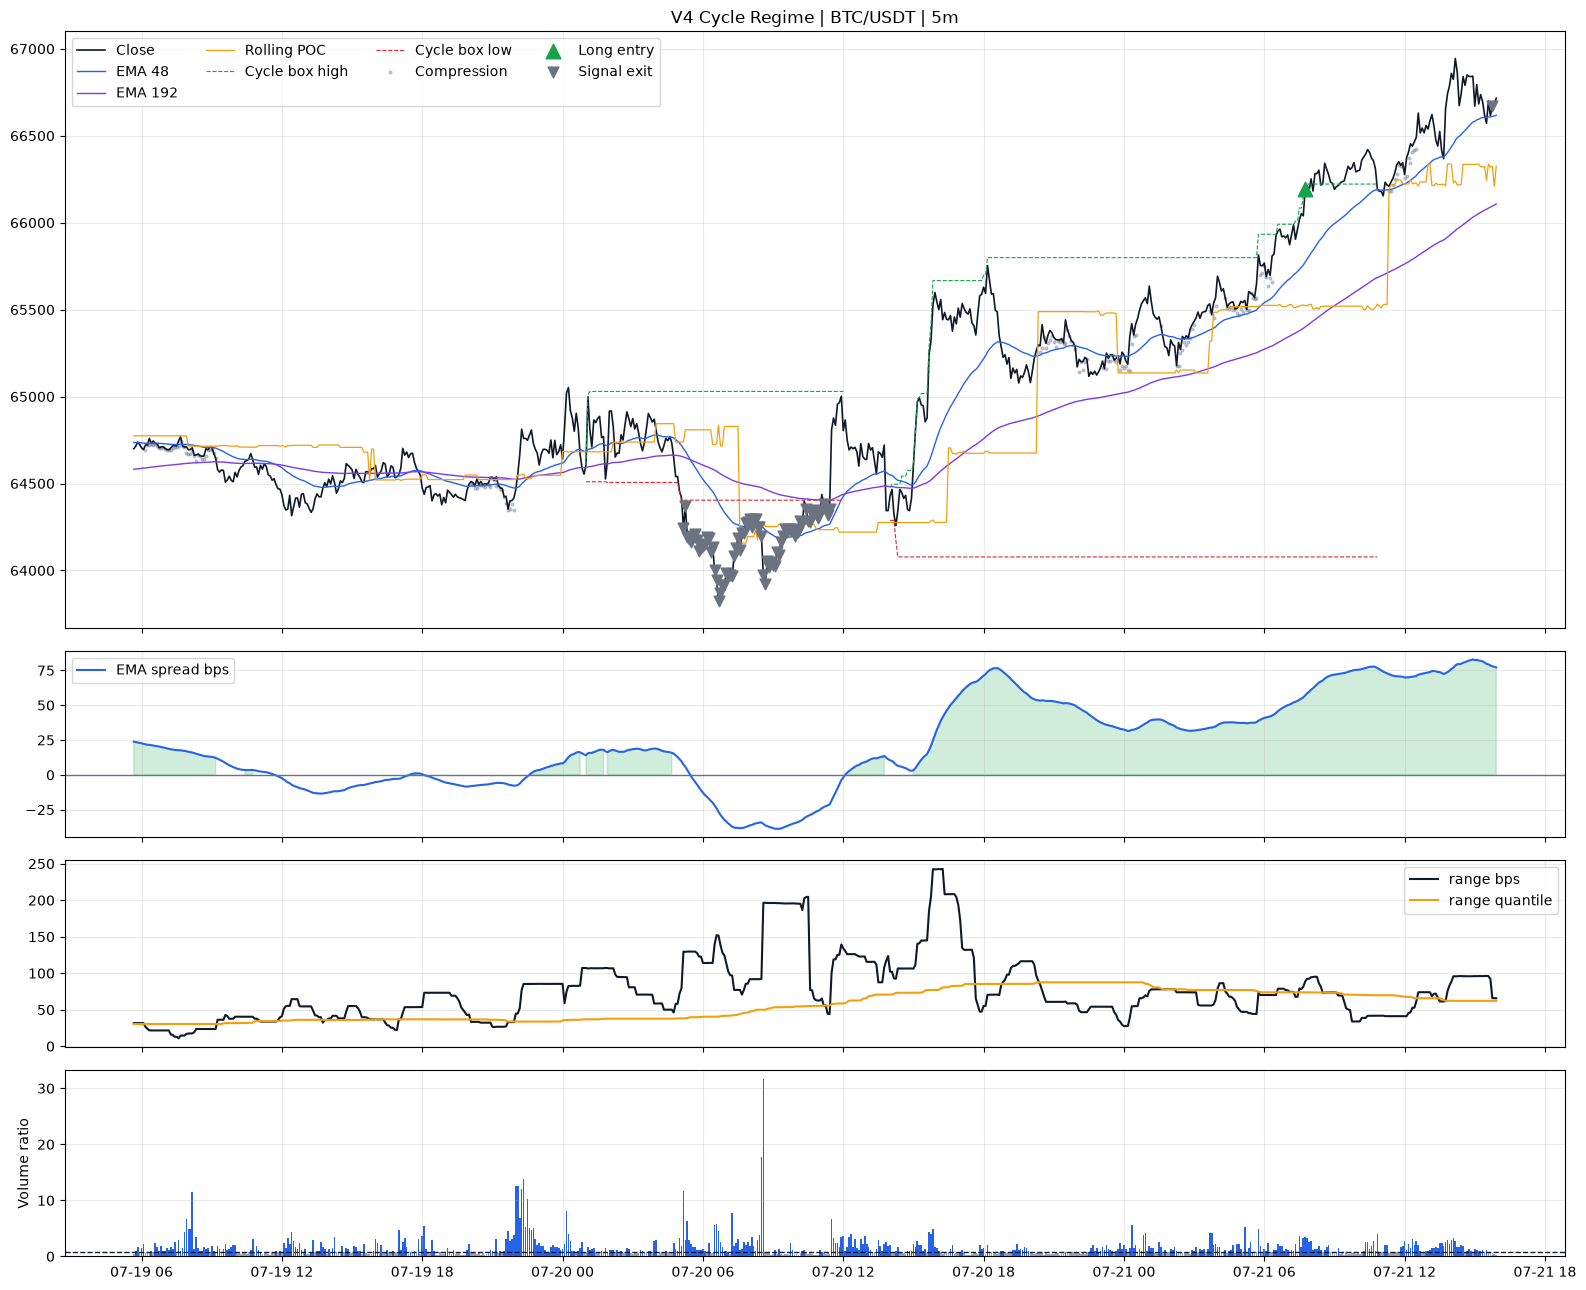

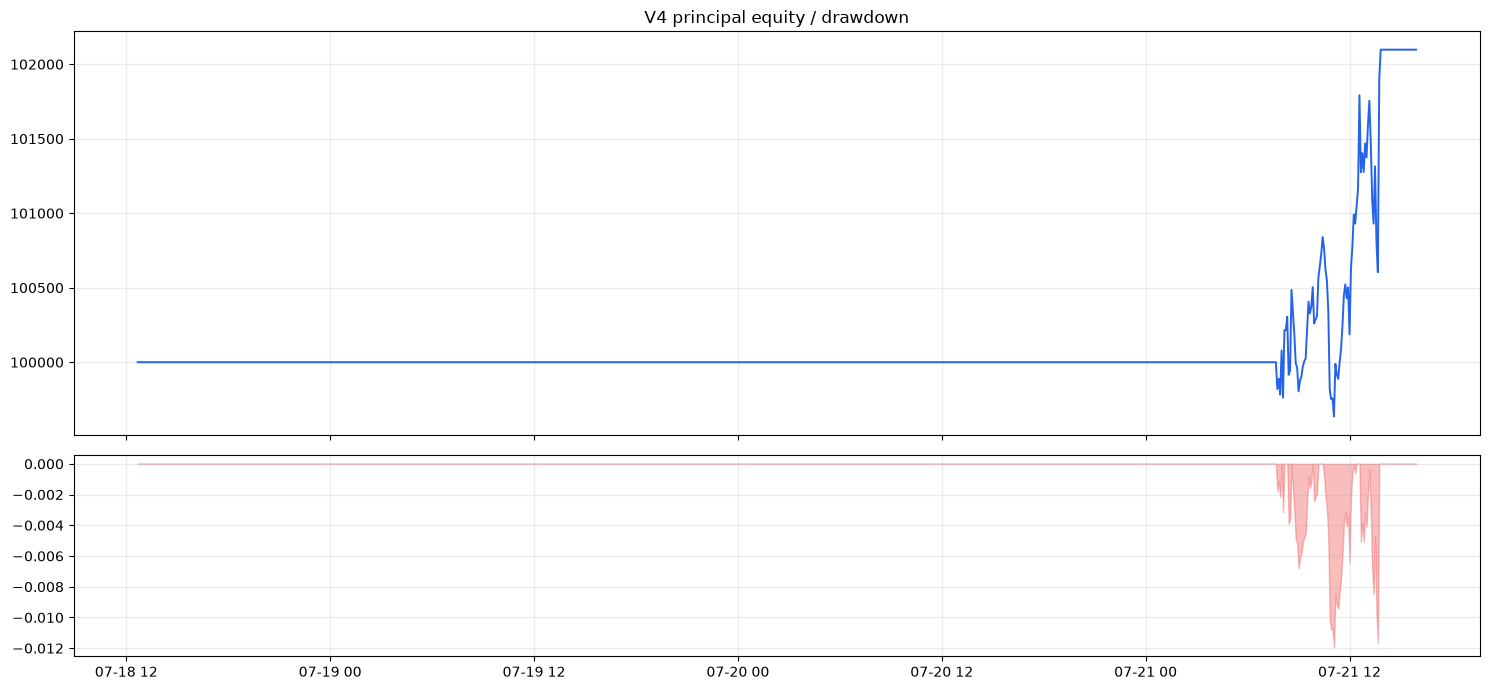

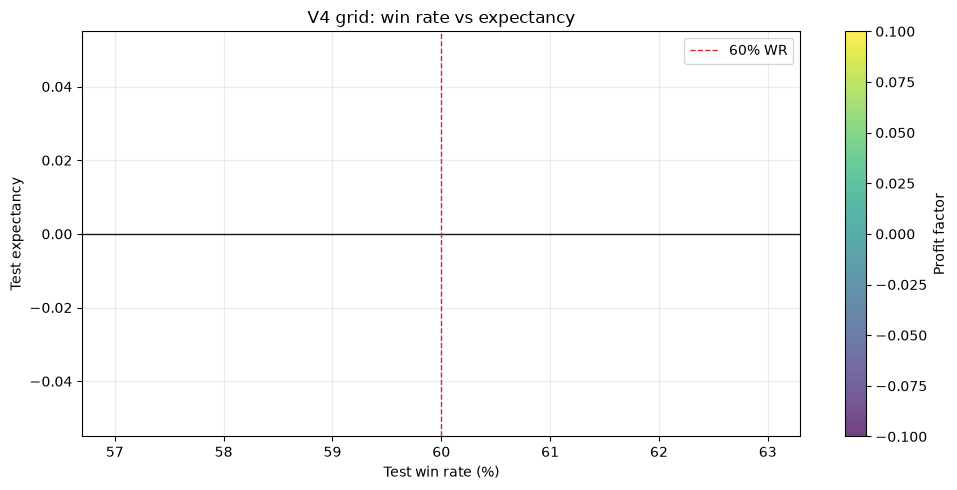

In [9]:
def plot_v4_cycle_strategy(f, pf, params=None, lookback=700):
    params = params or best_v4_params
    plot_f = f.tail(lookback).copy()
    entries, exits, _, _ = build_v4_signals(plot_f, params)

    fig, axes = plt.subplots(
        4, 1, figsize=(16, 13), sharex=True,
        gridspec_kw={"height_ratios": [3.2, 1.0, 1.0, 1.0]},
    )
    ax = axes[0]
    ax.plot(plot_f.index, plot_f["close"], color="#111827", linewidth=1.2, label="Close")
    ax.plot(plot_f.index, plot_f["ema_fast_sel"], color="#2563eb", linewidth=1.0, label=f"EMA {BEST_FAST}")
    ax.plot(plot_f.index, plot_f["ema_slow_sel"], color="#7c3aed", linewidth=1.0, label=f"EMA {BEST_SLOW}")
    ax.plot(plot_f.index, plot_f["poc"], color="#f59e0b", linewidth=0.9, label="Rolling POC")
    ax.plot(plot_f.index, plot_f["cycle_box_high"], color="#16a34a", linestyle="--", linewidth=0.8, label="Cycle box high")
    ax.plot(plot_f.index, plot_f["cycle_box_low"], color="#dc2626", linestyle="--", linewidth=0.8, label="Cycle box low")

    entry_idx = plot_f.index[entries.reindex(plot_f.index).fillna(False)]
    exit_idx = plot_f.index[exits.reindex(plot_f.index).fillna(False)]
    comp_idx = plot_f.index[plot_f["compression"].fillna(False)]
    if len(comp_idx):
        ax.scatter(comp_idx, plot_f.loc[comp_idx, "low"], marker=".", s=16, color="#64748b", alpha=0.35, label="Compression")
    if len(entry_idx):
        ax.scatter(entry_idx, plot_f.loc[entry_idx, "close"], marker="^", s=110, color="#16a34a", label="Long entry", zorder=6)
    if len(exit_idx):
        ax.scatter(exit_idx, plot_f.loc[exit_idx, "close"], marker="v", s=60, color="#6b7280", label="Signal exit", zorder=5)
    ax.set_title(f"V4 Cycle Regime | {CCXT_SYMBOL} | {TIMEFRAME}")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", ncols=4)

    axes[1].plot(plot_f.index, plot_f["ema_spread_bps"], color="#2563eb", label="EMA spread bps")
    axes[1].axhline(0, color="#6b7280", linewidth=1)
    axes[1].fill_between(plot_f.index, 0, plot_f["ema_spread_bps"], where=plot_f["real_uptrend"].fillna(False), color="#16a34a", alpha=0.20)
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.25)

    axes[2].plot(plot_f.index, plot_f["range_bps"], color="#111827", label="range bps")
    axes[2].plot(plot_f.index, plot_f["range_q"], color="#f59e0b", label="range quantile")
    axes[2].legend(loc="best")
    axes[2].grid(True, alpha=0.25)

    colors = np.where(plot_f["volume_ratio"] >= params.get("entry_vol_ratio_thr", 0.85), "#2563eb", "#94a3b8")
    axes[3].bar(plot_f.index, plot_f["volume_ratio"], color=colors, width=0.003)
    axes[3].axhline(params.get("entry_vol_ratio_thr", 0.85), color="#111827", linestyle="--", linewidth=1)
    axes[3].set_ylabel("Volume ratio")
    axes[3].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    principal_eq = principal_equity_from_pf(pf, params.get("leverage", LEVERAGE))
    dd = principal_eq / principal_eq.cummax() - 1
    fig, (eq_ax, dd_ax) = plt.subplots(2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    eq_ax.plot(principal_eq.index, principal_eq.values, color="#2563eb", linewidth=1.4)
    eq_ax.set_title("V4 principal equity / drawdown")
    eq_ax.grid(True, alpha=0.25)
    dd_ax.fill_between(dd.index, dd.values, 0, color="#ef4444", alpha=0.35)
    dd_ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_v4_grid(grid):
    if grid is None or grid.empty:
        print("V4 grid plot icin sonuc yok.")
        return
    fig, ax = plt.subplots(figsize=(10, 5))
    size = np.clip(grid["test_trades"], 1, None) * 25
    color = grid["test_profit_factor"].replace(np.inf, np.nan).clip(upper=5)
    sc = ax.scatter(grid["test_win_rate"] * 100, grid["test_expectancy"], s=size, c=color, cmap="viridis", alpha=0.75)
    ax.axhline(0, color="#111827", linewidth=1)
    ax.axvline(60, color="#dc2626", linestyle="--", linewidth=1, label="60% WR")
    ax.set_xlabel("Test win rate (%)")
    ax.set_ylabel("Test expectancy")
    ax.set_title("V4 grid: win rate vs expectancy")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    fig.colorbar(sc, ax=ax, label="Profit factor")
    plt.tight_layout()
    plt.show()


plot_v4_cycle_strategy(best_bt, pf_v4_best, best_v4_params, lookback=700)
plot_v4_grid(v4_grid)

## Strategy V4 Okuma Notu

Bu V4, screenshot'taki ana hatayi bilerek engeller:

- `real_uptrend` var diye her yerde long acmaz.
- Once pullback ve recovery ister.
- Sonra fiyat POC etrafinda dusuk range/dusuk ATR ile sikissin ister.
- Entry ancak sikismanin kutu ustu breakout/reclaim'inde gelir.
- `cooldown_bars` tekrar tekrar ayni yukselise binmeyi keser.
- `entry_vol_ratio_max` cok yuksek hacimli haber/panik spike'ina binmeyi keser.

MA heatmap sadece trend filtresini secmek icindir. Heatmap'te iyi gorunen MA ciftini direkt strateji diye trade etmek overfit olur; burada o cift sadece cycle state machine'e rejim bilgisi verir.

## Codex Actual V4 Quick Run

Son hizli dogrulama calismasi:

- Veri: BTC/USDT 5m, 3000 mum, `2026-07-11 06:00 UTC` -> `2026-07-21 15:55 UTC`.
- MA heatmap secimi: EMA fast `48`, EMA slow `288`.
- Trend-only MA heatmap tek basina guclu degil: en iyi train return bile negatife yakin/negatif. Bu yuzden MA sadece rejim filtresi olarak kullaniliyor.
- Cycle sayimi: 1 breakout entry. Eski spike/tepe kovalamalari `entry_vol_ratio_max=8` ve `entry_mom_bps_thr=20` ile elendi.
- V4 base/best: 1 trade, win rate 100%, principal return `+2.10%`, max drawdown `-1.19%`, trade PnL `+2097.76`.
- Trade: entry `2026-07-21 07:45 UTC`, exit `2026-07-21 13:50 UTC`.
- Risk: 3x leverage; configured stop `0.60%`, effective stop cap `0.213%`; stop-only principal risk yaklasik `0.64%`, fee/slippage buffer dahil `1.00%`.
- Grid robust train+test aday bulamadi; bu yuzden testte iyi gorunen parametre secilmedi, base V4 korundu.

Yorum: Bu artik V2'deki gibi yukselisin ortasinda surekli long basmiyor. Ama bu da istatistik degil; sadece anlatilan pattern'i daha dogru yakalayan ilk iskelet. Ciddi karar icin daha uzun veri, coin sepeti ve walk-forward gerekir.